# Monte Carlo Option Pricing

This project implements Monte Carlo pricing for European options
under the Black-Scholes model and compares the results with analytical
Black-Scholes prices.

The project investigates:

- Monte Carlo convergence
- Confidence intervals
- Antithetic variates
- Monte Carlo Greeks
- Common random numbers
- Finite-difference step-size sensitivity

Contents:
1. Introduction

2. Model Parameters

3. Monte-Carlo Stock Price and its Convergence

4. Convergence of Call Price

5. Variance Reduction: Antithetic Variates

6. Common Random Numbers: Calculating Delta

7. Put Price and the Put-Call Parity

8. More Greeks and their Finite-difference Step-size Sensitivity

9. Summary

# 1. Introduction

This project investigates Monte Carlo methods for pricing European options under the Black-Scholes model.

The primary objective is to implement a Monte Carlo option pricer in Python and compare its results with the analytical Black-Scholes solution. The project examines how Monte Carlo estimates converge as the number of simulations increases and how simulation uncertainty can be quantified using confidence intervals. Antithetic variates and common random numbers are also investigated.

Finally, I estimate option Greeks (Delta, Gamma and Vega) using finite differences and compare the Monte Carlo estimates with their analytical Black-Scholes counterparts.

# 2. Model Parameters

 - $S_0$: Current Stock Price
 - $r$: Risk-free interest rate
 - $\sigma$: Volatility
 - $T$: Time to maturity/years
 - $K$: Strike Price

In [1]:
import numpy as np
S_0=100       # current stock price
r=0.05       # risk-free interest rate
sigma=0.20   # volatility
T=1          # time to maturity (years)
K=100        # strike price

# 3. Monte Carlo Stock Price and its Convergence

We generate $N$ standard normal random variables $Z\sim N(0,1)$ and calculate the stock price for each $Z$ using the formula
\begin{equation}
    S_T = S_0 e^{\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}Z}
\end{equation}
which is the geometric Brownian motion model stochastic differential equation under risk-neutral measure $\text{d}S_t=rS_t\text{d}t+\sigma S_t\text{d}W_t$

As $N$ increases, the mean Monte Carlo estimate approaches the Black–Scholes benchmark while the standard deviation decreases $\propto\frac{1}{\sqrt{N}}$

In [2]:
from src.monte_carlo import monte_carlo_call_price
n_runs=100
results = []
for N in [100,1000,10000,100000]:
    prices = []
    for i in range(n_runs):
        prices.append(monte_carlo_call_price(S_0,r,sigma,T,K,N))
    print(N,np.mean(prices),np.std(prices))
    results.append({
        "N": N,
        "mean_price": np.mean(prices),
        "std_price": np.std(prices)
    })

#generates mean and standard deviation of stock prices for different number of simulations

9.428189664919078
11.068841894874948
10.463547297845873
10.457180181791287
10.459072202317717
100 10.336140841477443 1.4335097758526723
1000 10.396151754052353 0.4417252460436343
10000 10.431661352184356 0.1589764769137081
100000 10.453730599096941 0.04819099220872041


In [3]:
import pandas as pd
df = pd.DataFrame(results)
df

#table of results above

,N,mean_price,std_price
0,100,10.336141,1.433510
1,1000,10.396152,0.441725
2,10000,10.431661,0.158976
3,100000,10.453731,0.048191


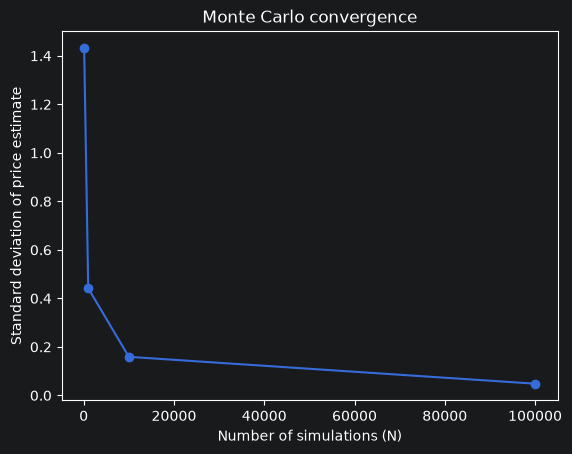

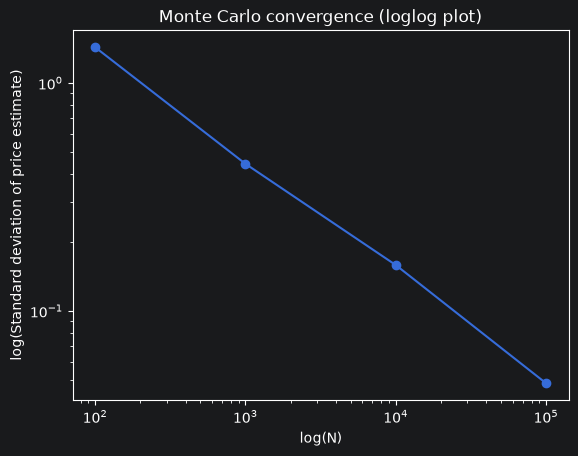

In [4]:
import matplotlib.pyplot as plt
plt.plot(df["N"], df["std_price"], marker="o")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation of price estimate")
plt.title("Monte Carlo convergence")
plt.show()
plt.loglog(df["N"], df["std_price"], marker="o")
plt.xlabel("log(N)")
plt.ylabel("log(Standard deviation of price estimate)")
plt.title("Monte Carlo convergence (loglog plot)")
plt.show()

#normal and log log plots of results above

In [5]:
x = np.log(df["N"])
y = np.log(df["std_price"])

slope, intercept = np.polyfit(x, y, 1)
print("Estimated convergence rate:", slope)

#gradient of log log plot is the estimated convergence rate; should be -0.5

Estimated convergence rate: -0.4864123725543714


# 4. Convergence of Call Price

The analytical call price $C_{\text{BS}}$ is given as
\begin{align}
    d_1&=\frac{\ln{\frac{S_0}{K}}+\left(r+\frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}} \\
    d_2&= d_1-\sigma\sqrt{T} \\
    C_{\text{BS}}&=S_0 N(d_1)-Ke^{-rT}N(d_2)
\end{align}
where $N(x)$ is the standard normal cdf

With the $S_T$ simulated in the previous section, the Monte-Carlo estimate for the call price $C_{MC}$ is given as
\begin{equation}
    C_{\text{MC}}=e^{-rT}\max(0,S_T-K)
\end{equation}
Similar to before, as $N$ increases, the standard error $SE=\frac{se^{-rT}}{\sqrt{N}}$, where $s$ is the sample standard deviation, decreases and the confidence interval $[C_{\text{MC}}-SE,C_{\text{MC}}+SE]$ closes in towards $C_\text{BS}$.

In [6]:
from src.black_scholes import call_price

bs_price = float(call_price(S_0,r,sigma,T,K))
print("Black-Scholes price:", bs_price)

#analytical Black-Scholes call price

10.450583572185565
0.6368306511756191
Black-Scholes price: 10.450583572185565


In [7]:
df["error"] = abs(df["mean_price"] - bs_price)
df["percentage_error"] = df["error"] / bs_price * 100
df

#columns added to table showing error between monte-carlo methods and theoretical

,N,mean_price,std_price,error,percentage_error
0,100,10.336141,1.433510,0.114443,1.095085
1,1000,10.396152,0.441725,0.054432,0.520850
2,10000,10.431661,0.158976,0.018922,0.181064
3,100000,10.453731,0.048191,0.003147,0.030113


In [8]:
results_ci = []
for N in [100,1000,10000,100000]:
    Z=np.random.normal(0,1,N)
    ST=S_0*np.exp((r-(sigma**2)/2)*T+sigma*np.sqrt(T)*Z)
    payoff=np.maximum(0,ST-K)
    payoff_mean=np.mean(payoff)
    payoff_std=np.std(payoff,ddof=1)
    prices=payoff_mean*np.exp(-r*T)
    standard_error = np.exp(-r * T) * payoff_std / np.sqrt(N)
    lower = prices - 1.96 * standard_error
    upper = prices + 1.96 * standard_error
    print(N,prices,standard_error,lower,upper)
    results_ci.append({
        "N": N,
        "monte_carlo_price": prices,
        "standard_error": standard_error,
        "lower_confidence_interval": lower,
        "upper_confidence_interval": upper
    })

#as number of simulations increase, standard deviation is smaller and the bounds close in towards the theoretical value

100 11.527241079991313 1.6639089394436486 8.265979558681762 14.788502601300864
1000 9.679931956341312 0.45590019055981956 8.786367582844065 10.573496329838559
10000 10.302476307354398 0.14600005625816928 10.016316197088386 10.58863641762041
100000 10.375402051006885 0.04638741523197135 10.28448271715222 10.46632138486155


In [9]:
df_ci = pd.DataFrame(results_ci)
df_ci

#table of results above

,N,monte_carlo_price,standard_error,lower_confidence_interval,upper_confidence_interval
0,100,11.527241,1.663909,8.265980,14.788503
1,1000,9.679932,0.455900,8.786368,10.573496
2,10000,10.302476,0.146000,10.016316,10.588636
3,100000,10.375402,0.046387,10.284483,10.466321


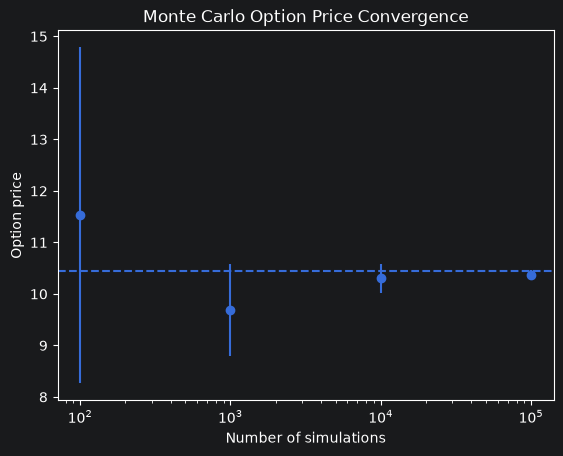

In [10]:
plt.errorbar(
    df_ci["N"],
    df_ci["monte_carlo_price"],
    yerr=1.96 * df_ci["standard_error"],
    fmt="o"
)

plt.axhline(bs_price, linestyle="--")

plt.xscale("log")
plt.xlabel("Number of simulations")
plt.ylabel("Option price")
plt.title("Monte Carlo Option Price Convergence")
plt.show()

#plot of results above, with error bars

# 5. Variance Reduction: Antithetic Variates

Antithetic variates reduce variance by averaging two values of stock price:
\begin{equation}
    S_{T\pm}=S_0 e^{\left(r - \frac{\sigma^2}{2}\right)T\pm\sigma\sqrt{T}Z}
\end{equation}
then using the average to calculate $C_{MC}$.

In the experiment, antithetic variates reduced variance by approximately 70–78%.

In [11]:
from src.antithetic import antithetic_call_price

price = antithetic_call_price(S_0,r,sigma,T,K,10000)
print(price)

#antithetic price

10.455127964055892


In [12]:
n_runs = 100
N = 10000

standard_prices = []
antithetic_prices = []
for i in range(n_runs):
    # Standard Monte Carlo
    standard_prices.append(monte_carlo_call_price(S_0, r, sigma, T, K, N))

    # Antithetic Monte Carlo
    antithetic_prices.append(antithetic_call_price(S_0,r,sigma,T,K,N))

print("Standard MC:")
print("Mean:", np.mean(standard_prices))
print("Std:", np.std(standard_prices))
print()
print("Antithetic MC:")
print("Mean:", np.mean(antithetic_prices))
print("Std:", np.std(antithetic_prices))

#mean and standard deviations of standard and antithetic prices; the standard deviation for standard is larger than antithetic

Standard MC:
Mean: 10.45947885426558
Std: 0.13281429286009688

Antithetic MC:
Mean: 10.459062810746378
Std: 0.07837513095623318


In [13]:
simulation_sizes = [100, 1000, 10000, 100000]
n_runs = 100
comparison_results = []

for N in simulation_sizes:
    standard_prices = []
    antithetic_prices = []
    for i in range(n_runs):
        # Standard Monte Carlo
        standard_prices.append(monte_carlo_call_price(S_0, r, sigma, T, K, N))

        # Antithetic Monte Carlo
        antithetic_prices.append(antithetic_call_price(S_0,r,sigma,T,K,N))
    comparison_results.append({
        "N": N,
        "standard_mean": np.mean(standard_prices),
        "standard_std": np.std(standard_prices),
        "antithetic_mean": np.mean(antithetic_prices),
        "antithetic_std": np.std(antithetic_prices)
    })

#varying number of simulations to acquire mean and std of standard and antithetic

In [14]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df

#table of results above

,N,standard_mean,standard_std,antithetic_mean,antithetic_std
0,100,10.436528,1.303761,10.356052,0.686727
1,1000,10.456203,0.452981,10.431246,0.245154
2,10000,10.485248,0.131271,10.447179,0.077011
3,100000,10.451120,0.040846,10.453826,0.022859


In [15]:
comparison_df["variance_reduction"] = (1 -(comparison_df["antithetic_std"] ** 2)
    / (comparison_df["standard_std"] ** 2)) * 100

comparison_df

#added percentage reduction of variance to table

,N,standard_mean,standard_std,antithetic_mean,antithetic_std,variance_reduction
0,100,10.436528,1.303761,10.356052,0.686727,72.255815
1,1000,10.456203,0.452981,10.431246,0.245154,70.710098
2,10000,10.485248,0.131271,10.447179,0.077011,65.583199
3,100000,10.451120,0.040846,10.453826,0.022859,68.679320


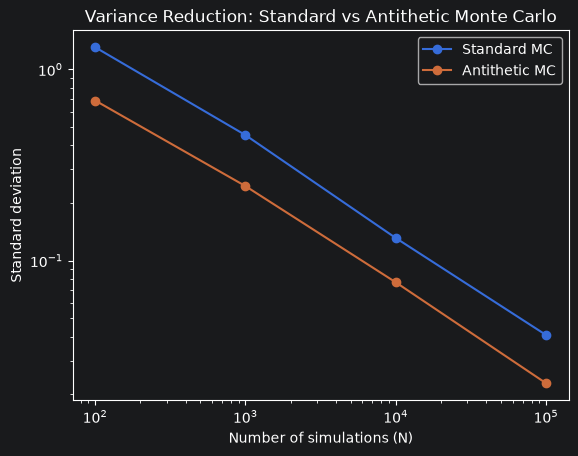

In [16]:
plt.loglog(
    comparison_df["N"],
    comparison_df["standard_std"],
    marker="o",
    label="Standard MC"
)

plt.loglog(
    comparison_df["N"],
    comparison_df["antithetic_std"],
    marker="o",
    label="Antithetic MC"
)

plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation")
plt.title("Variance Reduction: Standard vs Antithetic Monte Carlo")
plt.legend()
plt.show()

#log log plots of both standard and antithetic std

In [17]:
standard_se = comparison_df.loc[
    comparison_df["N"] == 100000, "standard_std"
].iloc[0]

antithetic_se = comparison_df.loc[
    comparison_df["N"] == 100000, "antithetic_std"
].iloc[0]

efficiency = (standard_se / antithetic_se) ** 2

print("Efficiency improvement:", efficiency)
print("Equivalent standard MC simulations:", 100000 * efficiency)

#efficiency calculation: how many more times of simulations standard need to keep up with antithetic

Efficiency improvement: 3.1927787257938296
Equivalent standard MC simulations: 319277.87257938297


# 6. Common Random Numbers: Calculating Delta

Delta is one of the Greeks, and is given analytically by
\begin{align}
    \Delta_{\text{BS}}&=\frac{\partial C_{\text{BS}}}{\partial S_0} \\
    &= N(d_1)
\end{align}

To approximate this using Monte-Carlo methods, the central finite-difference approximation is used:
\begin{equation}
    \Delta_{\text{MC}}=\frac{C_{\text{MC}}(S_0+h)-C_{\text{MC}}(S_0-h)}{2h}
\end{equation}
Common random numbers (CRNs) are used when calculating the perturbed option prices, causing much of the simulation noise to cancel when taking the finite difference.

In [18]:
from src.black_scholes import call_delta

bs_delta = call_delta(S_0,r, sigma, T,K)
print("Black-Scholes Delta:", bs_delta)

#theoretical Black-scholes delta

Black-Scholes Delta: 0.6368306511756191


In [19]:
h=1
N=100000
high_price=monte_carlo_call_price(S_0+h,r,sigma,T,K,N)
low_price=monte_carlo_call_price(S_0-h,r,sigma,T,K,N)
monte_carlo_delta=(high_price-low_price)/(2*h)

print("MC Delta:", monte_carlo_delta)
print("Black-Scholes Delta:", bs_delta)

#monte-carlo delta, but random errors are unrelated in high_price and low_price, so the errors are amplified

MC Delta: 0.595832496747037
Black-Scholes Delta: 0.6368306511756191


In [20]:
from src.monte_carlo import monte_carlo_call_price_crn
h=1
N=100000
Z=np.random.normal(0,1,N)
high_price=monte_carlo_call_price_crn(S_0+h,r,sigma,T,K,N,Z)
low_price=monte_carlo_call_price_crn(S_0-h,r,sigma,T,K,N,Z)
monte_carlo_delta=(high_price-low_price)/(2*h)

print("MC Delta:", monte_carlo_delta)
print("Black-Scholes Delta:", bs_delta)

#using common random numbers, results are much closer to theoretical

MC Delta: 0.6346658249633963
Black-Scholes Delta: 0.6368306511756191


In [21]:
h=1
N=100000
n_runs=100

independent_deltas=[]
crn_deltas=[]

for i in range(n_runs):
    #Independent
    high_price=monte_carlo_call_price(S_0+h,r,sigma,T,K,N)
    low_price=monte_carlo_call_price(S_0-h,r,sigma,T,K,N)
    independent_delta=(high_price-low_price)/(2*h)
    independent_deltas.append(independent_delta)

    #CRN
    Z=np.random.normal(0,1,N)
    high_price=monte_carlo_call_price_crn(S_0+h,r,sigma,T,K,N,Z)
    low_price=monte_carlo_call_price_crn(S_0-h,r,sigma,T,K,N,Z)
    crn_delta=(high_price-low_price)/(2*h)
    crn_deltas.append(crn_delta)

print("Independent random numbers")
print("Mean:", np.mean(independent_deltas))
print("Std:", np.std(independent_deltas))

print()

print("Common random numbers")
print("Mean:", np.mean(crn_deltas))
print("Std:", np.std(crn_deltas))

print()

print("Black-Scholes Delta:", bs_delta)

#Mean and std of independent and common deltas; std of common is much less than independet

Independent random numbers
Mean: 0.6439109741412434
Std: 0.03416324511661178

Common random numbers
Mean: 0.6366799182228648
Std: 0.0017549190810838067

Black-Scholes Delta: 0.6368306511756191


# 7. Put Price and the Put-Call Parity

The analytical put price $P_{\text{BS}}$ is given by
\begin{equation}
    P_{\text{BS}}=Ke^{-rT}N(-d_2)-S_0 N(-d_1)
\end{equation}
Since $N(-x)=1-N(x)$, we have the following relation:
\begin{align}
    C_{\text{BS}}-P_{\text{BS}}&=S_0 N(d_1)-Ke^{-rT}N(d_2)-Ke^{-rT}N(-d_2)+S_0 N(-d_1) \\
    &= S_0-Ke^{-rT}
\end{align}
which is the put-call parity.

The put and call prices acquired from Monte-Carlo methods must also satisfy this relation. Since randomness is involved, the errors are mainly due to independent random numbers, or difference in the sample mean $\mathbb{E}[S_T]$ if CRN is used.

In [22]:
from src.black_scholes import put_price
bs_put = put_price(S_0, r,sigma,T,K)
print("Black-Scholes put:", bs_put)

#analytical put price

Black-Scholes put: 5.573526022256971


In [23]:
LHS=bs_price-bs_put
RHS=S_0-K*np.exp(-r*T)
print("C - P:", LHS)
print("S0 - K exp(-rT):", RHS)
print("Difference:", abs(LHS-RHS))

#put-call parity check; for analytical difference is exactly 0

C - P: 4.877057549928594
S0 - K exp(-rT): 4.877057549928594
Difference: 0.0


In [24]:
from src.monte_carlo import monte_carlo_put_price_crn
N=100000
mc_put=monte_carlo_put_price_crn(S_0, r, sigma, T, K, N)
print("Monte Carlo put:", mc_put)
print("Black-Scholes put:", bs_put)

#monte_carlo put price

Monte Carlo put: 5.532238794888028
Black-Scholes put: 5.573526022256971


In [25]:
mc_price=monte_carlo_call_price(S_0,r,sigma,T,K,N)
lhs = mc_price - mc_put
rhs = S_0 - K * np.exp(-r * T)

print("Monte Carlo C - P:", lhs)
print("Put-call parity:", rhs)
print("Difference:", abs(lhs - rhs))

#put-call parity from monte-carlo methods (independent); not exact

Monte Carlo C - P: 4.884514738557805
Put-call parity: 4.877057549928594
Difference: 0.007457188629211409


In [26]:
mc_price_crn=monte_carlo_call_price_crn(S_0,r,sigma,T,K,N)
lhs=mc_price_crn-mc_put
rhs=S_0-K*np.exp(-r*T)

print("Monte Carlo C - P:", lhs)
print("Put-call parity:", rhs)
print("Difference:", abs(lhs - rhs))

#put-call parity from monte-carlo methods (common); not exact, but better; difference now depends on sample mean ST

Monte Carlo C - P: 4.909651239770137
Put-call parity: 4.877057549928594
Difference: 0.032593689841543316


# 8. More Greeks and their Finite-difference Step-size Sensitivity

Gamma and vega are two other Greeks. Analytically they are given by:
\begin{align}
    \Gamma_{\text{BS}}&=\frac{\partial^2 C}{\partial S_0^2} \\
    &= \frac{n(d_1)}{S_0\sigma\sqrt{T}} \\
    \nu_{\text{BS}}&=\frac{\partial C}{\partial \sigma} \\
    &= S_0 n(d_1)\sqrt{T}
\end{align}
where $n(x)$ is the standard normal pdf.

The same method for $\Delta_{\text{MC}}$ is used for $\nu_{\text{MC}}$, while for $\Gamma_{\text{MC}}$, the central second-difference is used:
\begin{equation}
    \Gamma_{\text{MC}}=\frac{C_{\text{MC}}(S_0+h)+C_{\text{MC}}(S_0-h)-2C_{\text{MC}}(S_0)}{h^2}
\end{equation}
The sensitivity of $\Gamma_{\text{MC}}$ to varying step sizes $h$ is then investigated. As $h$ decreases, the error decreases initially then increases when $h$ passes 1, which is due to the Monte-Carlo noise being amplified by dividing by $h^2<1$.

In [27]:
from src.black_scholes import call_gamma

bs_gamma=call_gamma(S_0, r, sigma, T, K)
print("Black-Scholes gamma:", bs_gamma)

#analytical gamma

Black-Scholes gamma: 0.018762017345846895


In [28]:
N = 100000
h = 1
Z=np.random.normal(0,1,N)
high_price=monte_carlo_call_price_crn(S_0+h,r,sigma,T,K,N,Z)
mid_price=monte_carlo_call_price_crn(S_0,r,sigma,T,K,N,Z)
low_price=monte_carlo_call_price_crn(S_0-h,r,sigma,T,K,N,Z)
crn_gamma=(high_price+low_price-2*mid_price)/(h**2)
print("Monte Carlo Gamma:", crn_gamma)
print("Black-Scholes Gamma:", bs_gamma)

#difference between common mc gamma and analytical

Monte Carlo Gamma: 0.018640057916147867
Black-Scholes Gamma: 0.018762017345846895


In [29]:
from src.black_scholes import call_vega

bs_vega=call_vega(S_0, r, sigma, T, K)
print("Black-Scholes vega:",bs_vega)

#analytical vega; this is per 1.00 change in sigma (volatility)

Black-Scholes vega: 37.52403469169379


In [30]:
N = 100000
h = 0.01
Z = np.random.normal(0, 1, N)
high_vol_price=monte_carlo_call_price_crn(S_0,r,sigma+h,T,K,N,Z)
low_vol_price=monte_carlo_call_price_crn(S_0,r,sigma-h,T,K,N,Z)
crn_vega=(high_vol_price-low_vol_price)/(h*2)
print("Monte Carlo vega:", crn_vega)
print("Black-Scholes vega:", bs_vega)

#monte-carlo vega and analytical

Monte Carlo vega: 37.497212546317456
Black-Scholes vega: 37.52403469169379


In [31]:
h_values = [5, 2, 1, 0.5, 0.2, 0.1]
gamma_results = []
N = 100000
for h in h_values:
    Z=np.random.normal(0,1,N)
    high_price=monte_carlo_call_price_crn(S_0+h,r,sigma,T,K,N,Z)
    mid_price=monte_carlo_call_price_crn(S_0,r,sigma,T,K,N,Z)
    low_price=monte_carlo_call_price_crn(S_0-h,r,sigma,T,K,N,Z)
    crn_gamma=(high_price+low_price-2*mid_price)/(h**2)
    gamma_error=abs(crn_gamma-bs_gamma)
    gamma_results.append({"h":h,"gamma":crn_gamma,"error":gamma_error})

#varying step size causes error of gamma to decrease THEN increase as the noise is amplified by dividing by h^2

In [32]:
gamma_df = pd.DataFrame(gamma_results)
gamma_df

#table of results above

,h,gamma,error
0,5.0,0.018584,0.000178
1,2.0,0.018581,0.000181
2,1.0,0.018614,0.000148
3,0.5,0.018357,0.000405
4,0.2,0.018288,0.000474
5,0.1,0.020265,0.001503


# 9. Summary

The Monte Carlo simulations produced option prices that converged towards
the analytical Black-Scholes price as the number of simulations increased.
The standard error decreased approximately with the expected
$O(N^{-1/2})$ behaviour.

Antithetic variates substantially reduced the variance of the Monte Carlo
price estimates. Common random numbers were particularly effective when
estimating Greeks using finite differences, reducing the standard deviation
of the Delta estimator from approximately 0.0319 to 0.00178 in the
experiment performed.

The Monte Carlo estimates of Delta, Gamma and Vega were also close to their
analytical Black-Scholes values. For example, the Monte Carlo estimates
were approximately:

- Delta: 0.6374 vs Black-Scholes 0.6368
- Gamma: 0.01869 vs Black-Scholes 0.01876
- Vega: 37.38 vs Black-Scholes 37.52

The Gamma step-size experiment demonstrated a trade-off between
finite-difference approximation error and Monte Carlo noise. While reducing
the step size can improve the finite-difference approximation, sufficiently
small step sizes amplify simulation noise.

Overall, the project demonstrates both the usefulness and limitations of
Monte Carlo methods in quantitative finance, as well as several techniques
for improving the accuracy and efficiency of simulation-based estimates.